In [7]:
# Building intuition for a simple but important idea:
# All other things being equal, the more rows of data the better for ML.

import numpy as np

np.random.seed(42)

# Small example
measurements = np.random.normal(loc=50, scale=10, size=10)
print("n = 10")
print("Measurements:", [f"{x:.1f}" for x in measurements])
print("Mean:", f"{measurements.mean():.1f}")
print("Standard Error of the Mean:", f"{(measurements.std(ddof=1) / np.sqrt(len(measurements))):.3f}")
print()

# Larger example
measurements = np.random.normal(loc=50, scale=10, size=1000)
print("n = 1000")
print("Measurements (first 20 shown):", [f"{x:.1f}" for x in measurements[:20]])
print("Mean:", f"{measurements.mean():.1f}")
print("Standard Error of the Mean:", f"{(measurements.std(ddof=1) / np.sqrt(len(measurements))):.3f}")
print()

# -------------------------------------------------------------------
# Generate a range of sample sizes from 10 to 1,000,000
# and record the mean and standard error for later plotting
# -------------------------------------------------------------------

# Log-spaced sample sizes: 10, 18, 34, ..., 1,000,000
sizes = np.unique(np.logspace(1, 6, num=30, dtype=int))

means = []
standard_errors = []

for n in sizes:
    measurements = np.random.normal(loc=50, scale=10, size=n)
    
    mean = measurements.mean()
    se = measurements.std(ddof=1) / np.sqrt(n)
    
    means.append(mean)
    standard_errors.append(se)

# Convert to NumPy arrays for easier plotting later
means = np.array(means)
standard_errors = np.array(standard_errors)

# Preview results
print("Recorded results:")
for n, mean, se in zip(sizes, means, standard_errors):
    print(f"n={n:>8,} | mean={mean:6.3f} | SE={se:8.5f}")

# These are now ready for plotting:
# sizes, means, standard_errors

n = 10
Measurements: ['55.0', '48.6', '56.5', '65.2', '47.7', '47.7', '65.8', '57.7', '45.3', '55.4']
Mean: 54.5
Standard Error of the Mean: 2.286

n = 1000
Measurements (first 20 shown): ['45.4', '45.3', '52.4', '30.9', '32.8', '44.4', '39.9', '53.1', '40.9', '35.9', '64.7', '47.7', '50.7', '35.8', '44.6', '51.1', '38.5', '53.8', '44.0', '47.1']
Mean: 50.2
Standard Error of the Mean: 0.310

Recorded results:
n=      10 | mean=53.803 | SE= 3.18039
n=      14 | mean=52.214 | SE= 2.62571
n=      22 | mean=51.765 | SE= 2.10390
n=      32 | mean=50.046 | SE= 1.86274
n=      48 | mean=52.563 | SE= 1.42719
n=      72 | mean=49.681 | SE= 1.26094
n=     108 | mean=50.697 | SE= 0.96026
n=     161 | mean=50.767 | SE= 0.77629
n=     239 | mean=50.769 | SE= 0.66104
n=     356 | mean=49.990 | SE= 0.51946
n=     529 | mean=50.070 | SE= 0.42709
n=     788 | mean=49.976 | SE= 0.35936
n=   1,172 | mean=49.534 | SE= 0.29265
n=   1,743 | mean=49.758 | SE= 0.23998
n=   2,592 | mean=49.980 | SE= 0.20389
n=

Text(0.5, 1.0, 'Mean vs Sample Size')

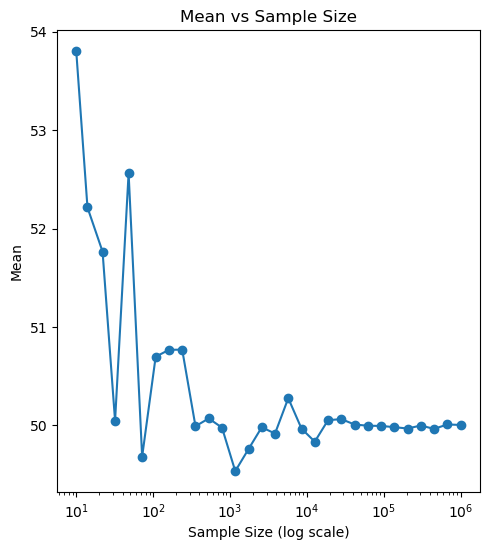

In [8]:
import matplotlib.pyplot as plt
# Plotting the mean as a function of sample size
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(sizes, means, marker='o')
plt.xscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Mean')
plt.title('Mean vs Sample Size')

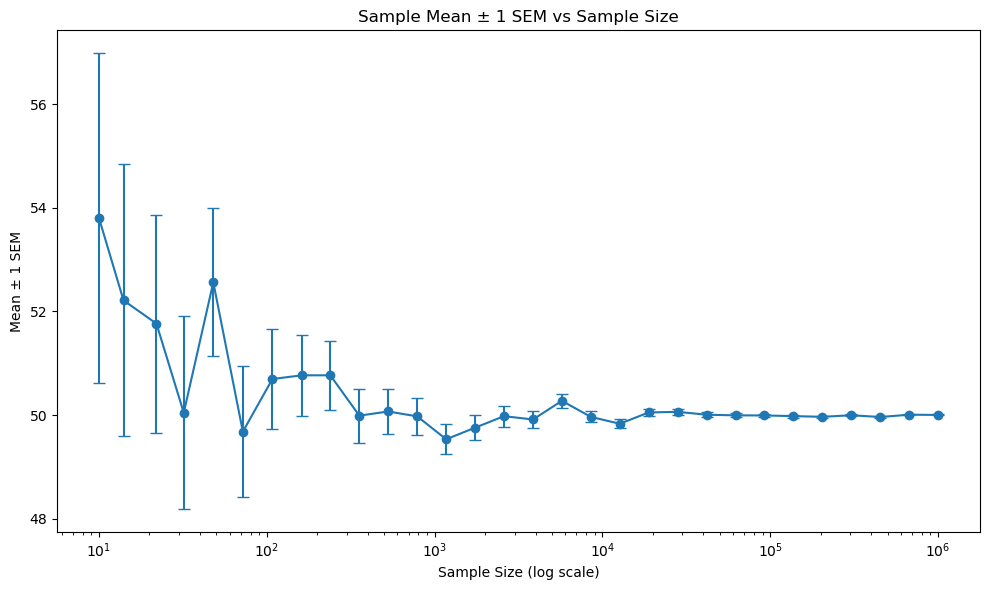

In [ ]:
import matplotlib.pyplot as plt

# Plot: Mean ± 1 Standard Error of the Mean (SEM)
plt.figure(figsize=(10, 6))

plt.errorbar(
    sizes,
    means,
    yerr=standard_errors,   # 1 SEM
    fmt='o-',
    capsize=4
)

plt.xscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Mean ± 1 SEM')
plt.title('Sample Mean ± 1 SEM vs Sample Size')


plt.tight_layout()
plt.show()

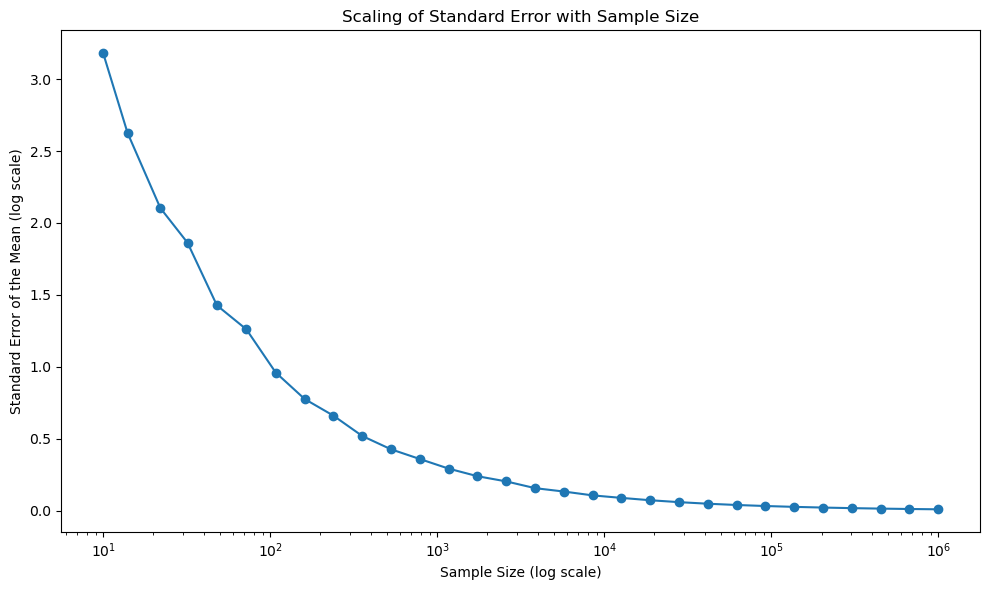

In [11]:
import matplotlib.pyplot as plt

# Separate plot: Standard error vs sample size
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    standard_errors,
    marker='o'
)

plt.xscale('log')
#plt.yscale('log')
plt.xlabel('Sample Size (log scale)')
plt.ylabel('Standard Error of the Mean (log scale)')
plt.title('Scaling of Standard Error with Sample Size')

plt.tight_layout()
plt.show()